In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ticker= "ETERNAL.NS"
data = yf.download(ticker,start="2022-01-01", end="2026-08-20")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS
Date,,,,,
2022-01-03,141.350006,142.449997,138.300003,139.699997,22518241
2022-01-04,138.350006,141.550003,137.600006,141.350006,10705792
2022-01-05,133.949997,137.899994,133.300003,137.899994,15874857
2022-01-06,130.000000,133.149994,129.600006,133.000000,23780419
2022-01-07,129.250000,131.449997,129.000000,130.000000,22846951


In [2]:
data['Daily Return'] = data['Close'].pct_change()
data.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS,ETERNAL.NS,
Date,,,,,,
2022-01-03,141.350006,142.449997,138.300003,139.699997,22518241,NaN
2022-01-04,138.350006,141.550003,137.600006,141.350006,10705792,-0.021224
2022-01-05,133.949997,137.899994,133.300003,137.899994,15874857,-0.031803
2022-01-06,130.000000,133.149994,129.600006,133.000000,23780419,-0.029489
2022-01-07,129.250000,131.449997,129.000000,130.000000,22846951,-0.005769


In [3]:
data['MA20'] =data['Close'].rolling(window=20).mean()
data['MA50'] =data['Close'].rolling(window=50).mean()
print(data[['Close','MA20','MA50']].tail(10))

Price            Close        MA20        MA50
Ticker      ETERNAL.NS                        
Date                                          
2026-08-06  316.250000  296.625002  274.912601
2026-08-07  315.000000  297.892502  276.201001
2026-08-10  310.250000  299.145001  277.444001
2026-08-11  318.000000  300.737502  278.789001
2026-08-12  314.049988  301.700002  280.130001
2026-08-13  318.000000  303.277501  281.403000
2026-08-14  318.500000  304.872501  282.643000
2026-08-17  318.000000  306.425000  284.037000
2026-08-18  315.899994  307.889999  285.442000
2026-08-19  320.000000  309.670000  287.046000


In [6]:
data['Signal'] = 0
data.loc[data['MA20'] > data['MA50'],'Signal'] = 1
data.loc[data['MA20'] < data['MA50'],'Signal'] = -1

In [7]:
print(data[['Close','MA20','MA50','Signal']].tail(20))

Price            Close        MA20        MA50 Signal
Ticker      ETERNAL.NS                               
Date                                                 
2026-07-23  287.100006  282.302502  263.100401      1
2026-07-24  280.000000  283.545003  263.876801      1
2026-07-27  295.850006  285.367503  264.965801      1
2026-07-28  308.350006  287.555003  266.188601      1
2026-07-29  311.799988  289.160002  267.557801      1
2026-07-30  310.649994  290.707501  268.929801      1
2026-07-31  302.450012  291.747502  270.139801      1
2026-08-03  310.500000  293.102502  271.396401      1
2026-08-04  312.399994  294.252502  272.641001      1
2026-08-05  310.350006  295.435002  273.717801      1
2026-08-06  316.250000  296.625002  274.912601      1
2026-08-07  315.000000  297.892502  276.201001      1
2026-08-10  310.250000  299.145001  277.444001      1
2026-08-11  318.000000  300.737502  278.789001      1
2026-08-12  314.049988  301.700002  280.130001      1
2026-08-13  318.000000  303.

In [9]:
daily_std = data['Daily Return'].std()
annualized_volatility = daily_std * np.sqrt(252)
print(annualized_volatility*100)

46.24175404030107


In [10]:
cumulative_returns = (1 + data['Daily Return']).cumprod()
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(max_drawdown)

-0.6989519357540489


In [11]:
data.to_excel("Eternal_Stock_Analysis.xlsx", sheet_name="Analysis")

In [20]:
data['Position'] = data['Signal'].diff()

buy_signals = data[data['Position'] == 2]
sell_signals = data[data['Position'] == -2]


print(data[['Signal', 'Position']].tail(30))

Price      Signal Position
Ticker                    
Date                      
2026-07-09      1      0.0
2026-07-10      1      0.0
2026-07-13      1      0.0
2026-07-14      1      0.0
2026-07-15      1      0.0
2026-07-16      1      0.0
2026-07-17      1      0.0
2026-07-20      1      0.0
2026-07-21      1      0.0
2026-07-22      1      0.0
2026-07-23      1      0.0
2026-07-24      1      0.0
2026-07-27      1      0.0
2026-07-28      1      0.0
2026-07-29      1      0.0
2026-07-30      1      0.0
2026-07-31      1      0.0
2026-08-03      1      0.0
2026-08-04      1      0.0
2026-08-05      1      0.0
2026-08-06      1      0.0
2026-08-07      1      0.0
2026-08-10      1      0.0
2026-08-11      1      0.0
2026-08-12      1      0.0
2026-08-13      1      0.0
2026-08-14      1      0.0
2026-08-17      1      0.0
2026-08-18      1      0.0
2026-08-19      1      0.0


In [23]:
print("Buy signals found:", len(buy_signals))
print("Sell signals found:", len(sell_signals))
print(buy_signals[['Close']])
print(sell_signals[['Close']])


Buy signals found: 10
Sell signals found: 9
Price            Close
Ticker      ETERNAL.NS
Date                  
2022-04-25   78.750000
2022-06-22   67.599998
2022-08-26   61.849998
2023-03-08   54.799999
2023-04-26   58.200001
2024-07-01  203.970001
2024-12-04  286.250000
2025-04-29  231.110001
2026-04-30  247.029999
2026-06-18  258.549988
Price            Close
Ticker      ETERNAL.NS
Date                  
2022-05-02   69.500000
2022-07-07   54.450001
2022-12-15   64.150002
2023-04-20   54.200001
2024-06-06  183.649994
2024-10-30  246.850006
2025-01-13  227.149994
2025-11-11  305.799988
2026-06-11  235.199997


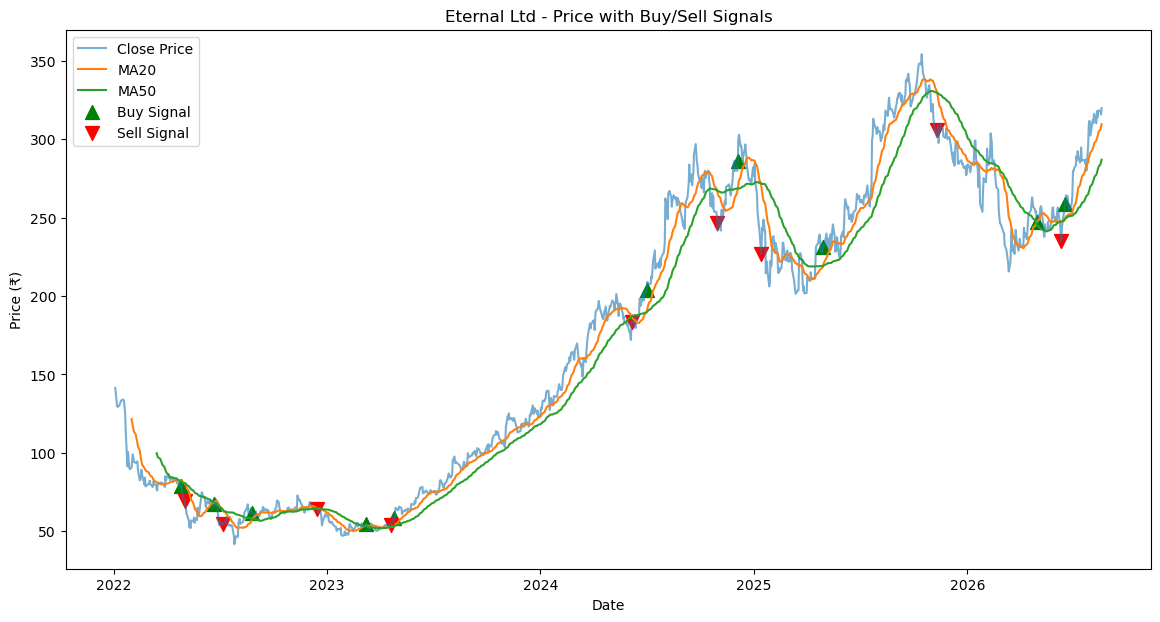

In [25]:
plt.figure(figsize=(14,7))
plt.plot(data['Close'], label='Close Price', alpha=0.6)
plt.plot(data['MA20'], label='MA20', linewidth=1.5)
plt.plot(data['MA50'], label='MA50', linewidth=1.5)
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', s=100, label='Buy Signal')
plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', s=100, label='Sell Signal')
plt.title('Eternal Ltd - Price with Buy/Sell Signals')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.show()